In [32]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
plt.style.use("ggplot")
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

from matplotlib.pyplot import figure
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

In [33]:
# Read the data
df = pd.read_csv(r'C:\Users\Aishw\dataset_prep.csv')

In [34]:
df.head()

,Title,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_date,released_year
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0,1980-06-13,1980.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,1980-07-02,1980.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,1980-06-20,1980.0
3,Airplane,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,1980-07-02,1980.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,1980-07-25,1980.0


In [35]:
# Look for missin data 
print(df.isnull().sum())

Title               0
rating              0
genre               0
year                0
released            2
score               1
votes               0
director            0
writer              1
star                0
country             2
budget           2171
gross              90
company            17
runtime             4
released_date      59
released_year      59
dtype: int64


In [39]:
#Predict Missing Budgets Using Regression
# Backing up original dataframe
df_original = df.copy()

# Separate the data: rows with known and unknown budgets
df_known = df[df['budget'].notna()]
df_unknown = df[df['budget'].isnull()]

In [40]:
numeric_features = ['runtime','score','gross','votes'] 
# Combine known and unknown data to process consistently
combined = pd.concat([df_known, df_unknown], sort=False)

combined = pd.get_dummies(combined, columns=['genre'],dummy_na = True)

genre_columns = [col for col in combined.columns if col.startswith('genre_')]
features = numeric_features + genre_columns


In [41]:
imputer = SimpleImputer(strategy = 'median')
combined[features] = imputer.fit_transform(combined[features])

In [42]:
#split again
df_known_processed = combined[combined['budget'].notna()]
df_unknown_processed = combined[combined['budget'].isna()]

In [43]:
X = df_known_processed[features]
y = df_known_processed['budget']

# Split: 80% train, 20% test
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],             # Number of trees
    'max_depth': [None, 10, 20, 30],        # Depth of each tree
    'min_samples_split': [2, 5],        # Minimum samples to split a node
    'min_samples_leaf': [1, 2],          # Minimum samples at leaf node
    'max_features': ['sqrt', 'log2', None] # Number of features to consider
}

# Instantiate model
rf = RandomForestRegressor(random_state=42)

# Grid Search with 5-fold cross-validation using R² as scoring
grid_search = GridSearchCV(estimator=rf, 
                           param_grid=param_grid,
                           cv=5, 
                           scoring='r2',
                           n_jobs=-1, # Use all CPU cores
                           verbose=2)

# Fit the grid search on training data
grid_search.fit(X_train, y_train)

# Best model after hyperparameter tuning
best_model = grid_search.best_estimator_

# Predict using the best model
y_val_pred = best_model.predict(X_val)

# Evaluation
mae = mean_absolute_error(y_val, y_val_pred)
mse = mean_squared_error(y_val, y_val_pred)
rmse = mse ** 0.5
r2 = r2_score(y_val, y_val_pred)

print("Best Hyperparameters:", grid_search.best_params_)
print(f"MAE : {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²   : {r2:.3f}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
MAE : 14,339,592
RMSE: 22,117,639
R²   : 0.692


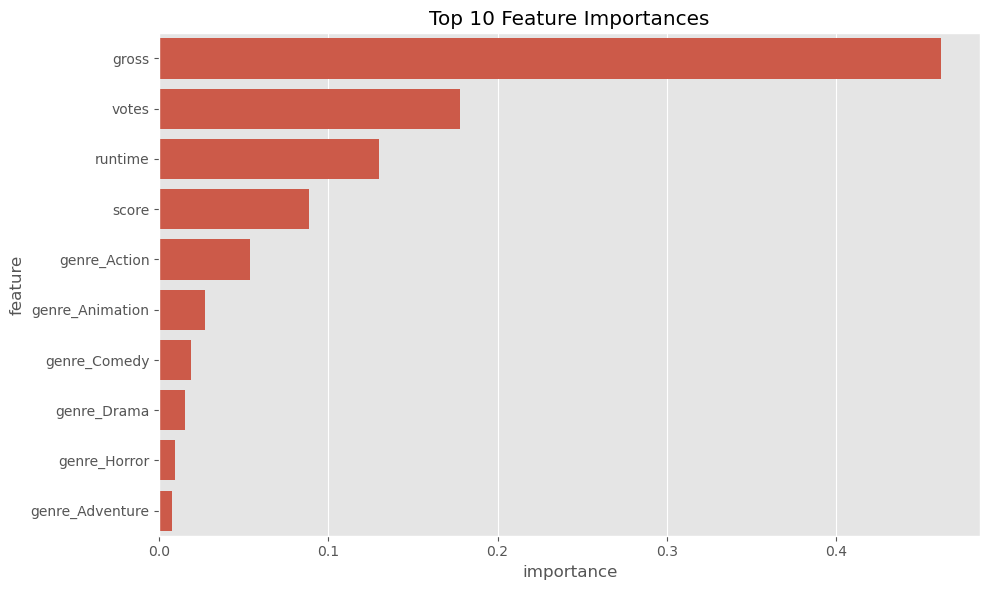

In [45]:
#Feature Importance plot
importances = grid_search.best_estimator_.feature_importances_
feat_imp_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_imp_df.head(10))
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

In [46]:
X_known = combined.loc[df['budget'].notna(), features]
y_known = df_known['budget']
X_unknown = combined.loc[df['budget'].isna(), features]
y_known_log = np.log1p(y_known)

In [47]:
final_model = RandomForestRegressor(
    max_depth=30,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

In [48]:
final_model.fit(X_known, y_known_log)

RandomForestRegressor(max_depth=30, max_features='sqrt', random_state=42)

In [49]:
y_missing_log = final_model.predict(X_unknown)
y_missing_pred = np.expm1(y_missing_log)

In [50]:
df['budget_was_predicted'] = df['budget'].isna()  # Before filling
df.loc[df['budget_was_predicted'], 'budget'] = y_missing_pred

In [51]:
print("Remaining missing budget values:", df['budget'].isna().sum())

Remaining missing budget values: 0


In [52]:
df.to_csv('dataset_filled.csv', index=False)